In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 전처리 인터페이스 임포트
from src.pipeline import load_processed

# 시각화 스타일 및 한글 깨짐 방지 설정
plt.style.use('seaborn-v0_8-whitegrid')
plt.rc('font', family='Malgun Gothic') 
plt.rc('axes', unicode_minus=False)

print("데이터셋 로딩 중...")
X_train, X_test, y_train, y_test = load_processed("hit", with_text=False)
print(f"로드 완료. 학습 데이터 크기: {X_train.shape}")

데이터셋 로딩 중...
로드 완료. 학습 데이터 크기: (37257, 83)


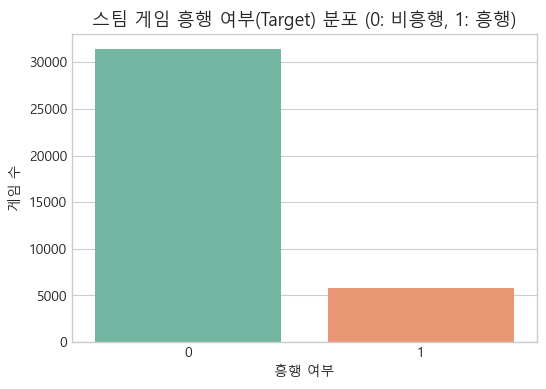

전체 데이터 중 흥행 성공작 비율: 15.63%


In [2]:
plt.figure(figsize=(6, 4))
sns.countplot(x=y_train, hue=y_train, palette='Set2', legend=False)
plt.title("스팀 게임 흥행 여부(Target) 분포 (0: 비흥행, 1: 흥행)", fontsize=13)
plt.xlabel("흥행 여부")
plt.ylabel("게임 수")
plt.show()

hit_rate = y_train.mean() * 100
print(f"전체 데이터 중 흥행 성공작 비율: {hit_rate:.2f}%")

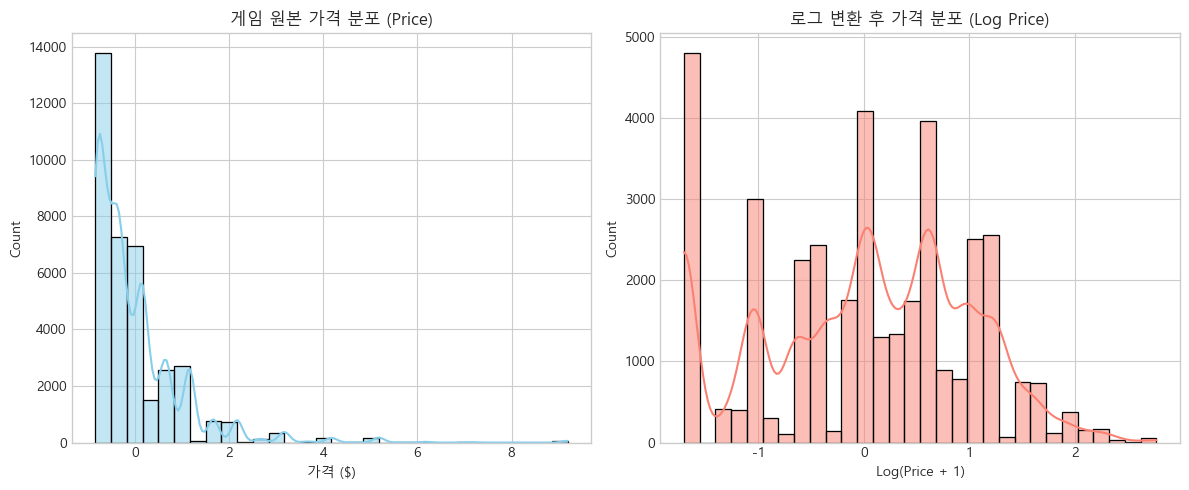

원본 가격은 무료 게임(0달러)에 극단적으로 쏠려 있어 왜도가 심하지만, 로그 변환(log_price)을 통해 데이터가 정규분포에 가깝게 완화된 것을 확인할 수 있습니다.


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 1. 원본 가격 분포
sns.histplot(X_train['price'], bins=30, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title("게임 원본 가격 분포 (Price)", fontsize=12)
axes[0].set_xlabel("가격 ($)")

# 2. 로그 변환 가격 분포
sns.histplot(X_train['log_price'], bins=30, kde=True, ax=axes[1], color='salmon')
axes[1].set_title("로그 변환 후 가격 분포 (Log Price)", fontsize=12)
axes[1].set_xlabel("Log(Price + 1)")

plt.tight_layout()
plt.show()

print("원본 가격은 무료 게임(0달러)에 극단적으로 쏠려 있어 왜도가 심하지만, 로그 변환(log_price)을 통해 데이터가 정규분포에 가깝게 완화된 것을 확인할 수 있습니다.")

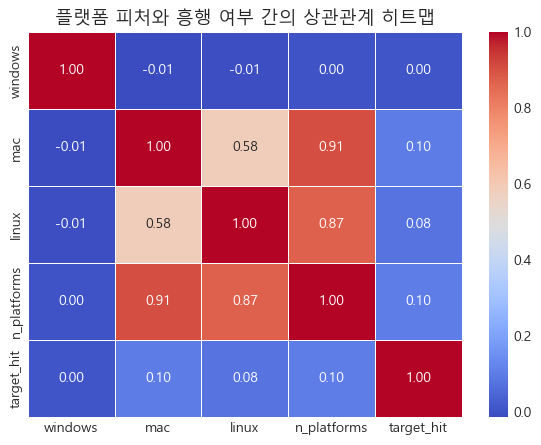

In [4]:
platform_cols = ['windows', 'mac', 'linux', 'n_platforms']
platform_df = X_train[platform_cols].copy()
platform_df['target_hit'] = y_train

corr_matrix = platform_df.corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("플랫폼 피처와 흥행 여부 간의 상관관계 히트맵", fontsize=13)
plt.show()

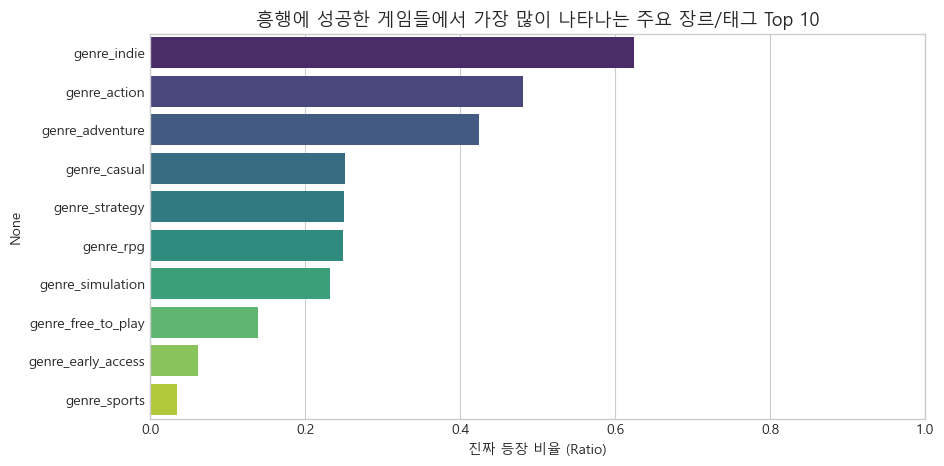

In [ ]:
genre_cols = [col for col in X_train.columns if 'genre' in col.lower() or 'tag' in col.lower()][:10]

if genre_cols:
    genre_df = X_train[genre_cols].copy()
    genre_df['target_hit'] = y_train
    
    # StandardScaler(표준화)로 인해 왜곡된 수치를 0과 1 상태로 복원합니다.
    # 각 컬럼의 최솟값(0이었던 값)을 빼고, 최댓값과 최솟값의 차이로 나누어 0~1 범위로 미니맥스 변환합니다.
    for col in genre_cols:
        col_min = genre_df[col].min()
        col_max = genre_df[col].max()
        if col_max != col_min:
            genre_df[col] = (genre_df[col] - col_min) / (col_max - col_min)
        else:
            genre_df[col] = 0.0 # 모든 값이 같을 경우 예외 처리
   
    hit_genres = genre_df[genre_df['target_hit'] == 1][genre_cols].mean().sort_values(ascending=False)
    
    plt.figure(figsize=(10, 5))
    sns.barplot(x=hit_genres.values, y=hit_genres.index, hue=hit_genres.index, palette='viridis', legend=False)
    plt.title("흥행에 성공한 게임들에서 가장 많이 나타나는 주요 장르/태그 Top 10", fontsize=13)
    plt.xlabel("등장 비율 (Ratio)") # 축 이름 변경
    plt.xlim(0, 1.0) # 축 범위가 0부터 1(100%) 사이에만 위치하도록 고정
    plt.show()
else:
    print("장르 혹은 태그 컬럼을 찾을 수 없습니다. X_train.columns 명칭을 확인하세요.")